# Optimal Transport in linear ICA

#### In this notebook we test the performance of a OT ICA on Stiefel Manifold (Orthogonal mtx space) versus Fast ICA over dimensions.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from tqdm.notebook import tqdm
import time
from joblib import Parallel, delayed
from wasserstein_ica import WassersteinICA

In [2]:
# ==========================================
# 1. Helpers & Data Generation
# ==========================================

def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
        
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    
    return (term1 + term2) / (2 * n)

def generate_dataset(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Standard Laplace (Super-Gaussian)
    sources = [np.random.laplace(0, 1, n_samples) for _ in range(n_dim)]
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

In [3]:
# ==========================================
# 2. Experiment Setup
# ==========================================

# Test a range of dimensions up to 30
DIMENSIONS = [n for n in range(10, 100)]  # Varying D
N_SAMPLES = 5000
N_TRIALS = 5  # Run multiple trials for error bars

print(f"--- FastICA vs. OT Stiefel ICA---")
print(f"Dimensions: {DIMENSIONS}")
print(f"Samples: {N_SAMPLES}")
print(f"Trials per dim: {N_TRIALS}")

results = []

--- FastICA vs. OT Stiefel ICA---
Dimensions: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Samples: 5000
Trials per dim: 5


In [ ]:
# ==========================================
# 3. The Parallel Worker Function
# ==========================================
def run_single_trial(dim, trial, n_samples):
    """
    Isolated function to run a single trial. 
    Returns a list of dictionaries with timing and Amari errors.
    """
    # CRITICAL: Force PyTorch to use exactly 1 thread per process.
    # Otherwise, all 12 workers will try to spawn 16 threads each, 
    # creating a gridlock of 192 threads that will crash performance.
    torch.set_num_threads(1)
    
    trial_results = []

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Generate Data
    X_torch, A_true = generate_dataset(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    
    # Pull back to CPU for Scikit-learn's FastICA
    X_np = X_torch.cpu().numpy()
    
    # -----------------------------------
    # TIMING: FastICA (Baseline)
    # -----------------------------------
    t0_fast = time.perf_counter()
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
    t_fast_total = time.perf_counter() - t0_fast
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Amari Error': score_fast,
        'Phase 1 Time (s)': np.nan,
        'Phase 2 Time (s)': np.nan,
        'Total Time (s)': t_fast_total
    })
    
    # -----------------------------------
    # TIMING: Standalone WassersteinICA 
    # -----------------------------------
    ica = WassersteinICA(X_torch)
    ica.whiten()
    W_white_np = ica.W_white.cpu().numpy()
    
    try:
        # Phase 1: Robust Deflation
        t0_p1 = time.perf_counter()
        extracted_ws = []
        #n_restarts = dim * 4 if dim * 4 < 150 else 150
        n_restarts = dim * 4
        
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts)
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        t_phase1 = time.perf_counter() - t0_p1
        
        # Phase 2: Stiefel Manifold Polish
        t0_p2 = time.perf_counter()
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=200, 
            lr=1.0, 
            init_w=W_deflation_init, 
            optimizer='stiefel',
        )
        t_phase2 = time.perf_counter() - t0_p2
        
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception:
        score_wass = np.nan
        t_phase1 = np.nan
        t_phase2 = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'W-ICA (Stiefel)', 
        'Amari Error': score_wass,
        'Phase 1 Time (s)': t_phase1,
        'Phase 2 Time (s)': t_phase2,
        'Total Time (s)': t_phase1 + t_phase2 if not np.isnan(t_phase1) else np.nan
    })
    
    return trial_results

In [5]:
# ==========================================
# 4. Execute Main Loop with Joblib
# ==========================================
# Create a flat list of arguments for all 200 tasks
tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

# Execute tasks in parallel across 12 processes
results_nested = Parallel(n_jobs=12)(
    delayed(run_single_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Trials Parallel")
)

# Flatten the nested list of results
results = [item for sublist in results_nested for item in sublist]

# ==========================================
# 5. Reporting the Time & Accuracy Table
# ==========================================
df = pd.DataFrame(results)

# Group by Dimension and Method to get the average across trials
summary_table = df.groupby(['Dimension', 'Method']).mean().reset_index()

# Formatting for a clean read
pd.set_option('display.float_format', lambda x: '%.4f' % x)
display(summary_table[['Dimension', 'Method', 'Amari Error', 'Phase 1 Time (s)', 'Phase 2 Time (s)', 'Total Time (s)']])

Running Trials Parallel:   0%|          | 0/450 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/p

,Dimension,Method,Amari Error,Phase 1 Time (s),Phase 2 Time (s),Total Time (s)
0,10,FastICA,0.1183,NaN,NaN,0.0101
1,10,W-ICA (Stiefel),0.1098,6.1824,1.9819,8.1643
2,11,FastICA,0.1281,NaN,NaN,0.0140
3,11,W-ICA (Stiefel),0.1194,6.9255,1.1985,8.1240
4,12,FastICA,0.1401,NaN,NaN,0.0121
...,...,...,...,...,...,...
175,97,W-ICA (Stiefel),13.5052,172.0241,36.1688,208.1929
176,98,FastICA,1.2988,NaN,NaN,0.2107
177,98,W-ICA (Stiefel),13.5808,166.7460,25.6456,192.3916
178,99,FastICA,1.3123,NaN,NaN,0.2687


In [6]:
"""
# ==========================================
# 3. Main Loop
# ==========================================

for dim in tqdm(DIMENSIONS, desc="Dimensions"):
    for trial in range(N_TRIALS):
        # 1. Generate Data
        X_torch, A_true = generate_dataset(n_dim=dim, n_samples=N_SAMPLES, seed=trial)
        X_np = X_torch.numpy()
        
        # 2. FastICA (Baseline)
        try:
            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
            fast_ica.fit(X_np.T)
            W_fast_total = fast_ica.components_
            score_fast = amari_error(W_fast_total, A_true)
        except Exception as e:
            score_fast = np.nan
            W_fast_total = None
            
        results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
        
        # 3. Initialize WassersteinICA
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        # 4. Standalone WassersteinICA (Phase 1 + Stiefel Manifold Polish)
        try:
            # PHASE 1: Robust Deflation (Find the mountains)
            extracted_ws = []
            n_restarts = dim * 4 if dim * 4 < 150 else 150
            for _ in range(dim):
                prev = torch.stack(extracted_ws) if extracted_ws else None
                # Using dynamic restarts to guarantee we avoid local minima in high dims
                w, _ = ica.optimize_wasserstein2(prev_components=prev, max_iter=200, n_restarts=n_restarts)
                extracted_ws.append(w)
            W_deflation_init = torch.stack(extracted_ws)
            
            # PHASE 2: Stiefel Manifold (Climb the peaks while staying strictly orthogonal)
            W_stiefel_unmixed = ica.optimize_symmetric(
                n_components=dim, 
                max_iter=200, 
                lr=1.0, 
                init_w=W_deflation_init, 
                optimizer='stiefel',
            )
            
            # No final orthogonalization needed; Stiefel guarantees W @ W.T = I
            W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
            score_wass = amari_error(W_wass_total, A_true)
            
        except Exception as e:
            print(f"Failed at dim {dim}: {e}")
            score_wass = np.nan
            
        results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
"""

'\n# ==========================================\n# 3. Main Loop\n# ==========================================\n\nfor dim in tqdm(DIMENSIONS, desc="Dimensions"):\n    for trial in range(N_TRIALS):\n        # 1. Generate Data\n        X_torch, A_true = generate_dataset(n_dim=dim, n_samples=N_SAMPLES, seed=trial)\n        X_np = X_torch.numpy()\n\n        # 2. FastICA (Baseline)\n        try:\n            fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)\n            fast_ica.fit(X_np.T)\n            W_fast_total = fast_ica.components_\n            score_fast = amari_error(W_fast_total, A_true)\n        except Exception as e:\n            score_fast = np.nan\n            W_fast_total = None\n\n        results.append({\'Dimension\': dim, \'Method\': \'FastICA\', \'Amari Error\': score_fast})\n\n        # 3. Initialize WassersteinICA\n        ica = WassersteinICA(X_torch)\n        ica.whiten()\n        W_white_np = ica.W_white.cpu().numpy()\n\n        # 4. St

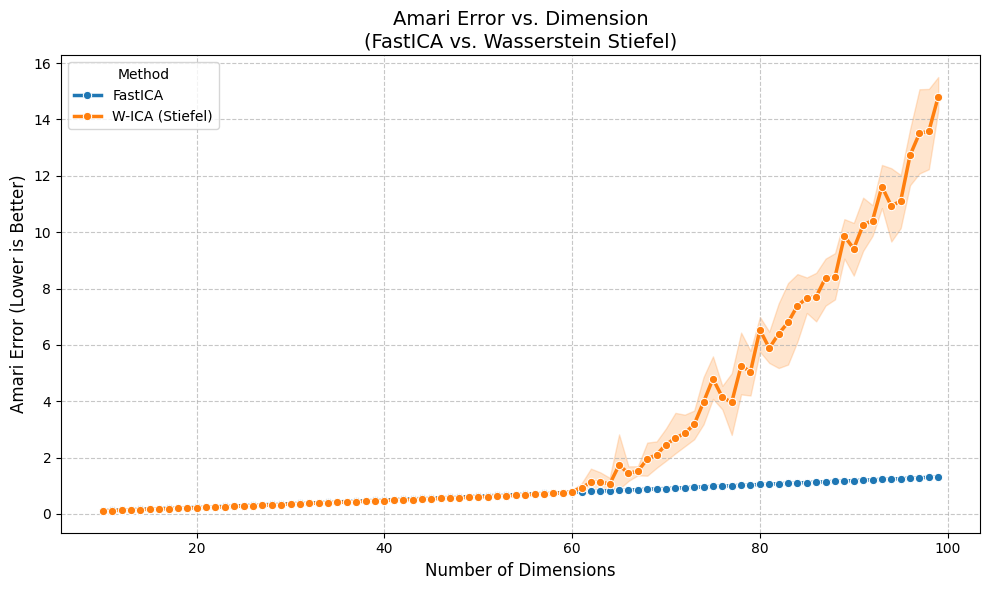

Method,FastICA,W-ICA (Stiefel)
Dimension,,
10,0.1183,0.1098
11,0.1281,0.1194
12,0.1401,0.1305
13,0.1550,0.1448
14,0.1650,0.1546
...,...,...
95,1.2530,11.1083
96,1.2682,12.7296
97,1.2838,13.5052


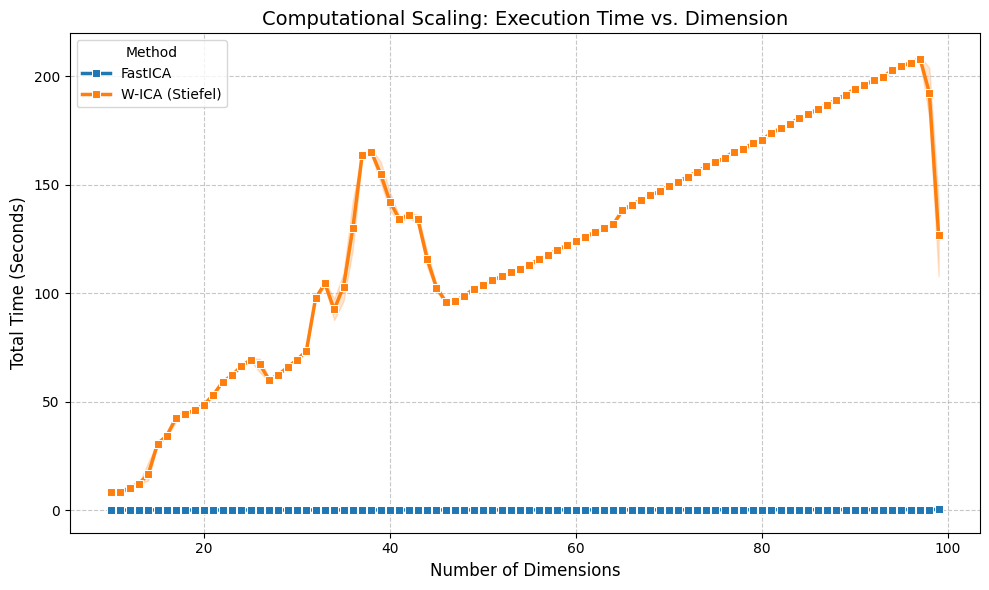


--- W-ICA Time Breakdown ---


,Phase 1 Time (s),Phase 2 Time (s),Total Time (s)
Dimension,,,
10,6.1800,1.9800,8.1600
11,6.9300,1.2000,8.1200
12,7.7700,2.5900,10.3600
13,9.4500,2.7500,12.2000
14,10.9200,5.5100,16.4300
...,...,...,...
95,167.7500,37.0000,204.7500
96,167.6700,38.5800,206.2400
97,172.0200,36.1700,208.1900


In [7]:
# ==========================================
# 6. Plotting the Results
# ==========================================

# Your original Amari Error Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title("Amari Error vs. Dimension\n(FastICA vs. Wasserstein Stiefel)", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log') 
plt.tight_layout()
plt.show()

# Display mean scores table
display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))

# ------------------------------------------
# NEW: Total Execution Time Plot
# ------------------------------------------
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Dimension', y='Total Time (s)', hue='Method', marker='s', linewidth=2.5)
plt.title("Computational Scaling: Execution Time vs. Dimension", fontsize=14)
plt.ylabel("Total Time (Seconds)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display time breakdown table for W-ICA
w_ica_times = df[df['Method'] == 'W-ICA (Stiefel)'].groupby('Dimension')[['Phase 1 Time (s)', 'Phase 2 Time (s)', 'Total Time (s)']].mean()
print("\n--- W-ICA Time Breakdown ---")
display(w_ica_times.round(2))

## What happens if we only do Stiefel step i.e. Phase 2, without Phase 1 with SGD

In [8]:


# ==========================================
# 1. Experiment Setup
# ==========================================
DIMENSIONS = [n for n in range(10, 21)]  # 10 to 20 dimensions
N_SAMPLES = 5000
N_TRIALS = 5  

print(f"--- FastICA vs. W-ICA (Stiefel Cold Start Only) ---")
print(f"Dimensions: {DIMENSIONS[0]} to {DIMENSIONS[-1]}")
print(f"Learning Rate: 0.1")

# ==========================================
# 2. Parallel Worker Function
# ==========================================
def run_cold_start_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []
    
    # Generate standard Laplace data for a clear baseline
    X_torch, A_true = generate_dataset(n_dim=dim, n_samples=n_samples, seed=trial)
    X_np = X_torch.numpy()
    
    # --- FastICA (Baseline) ---
    t0_fast = time.perf_counter()
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception:
        score_fast = np.nan
    t_fast_total = time.perf_counter() - t0_fast
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Amari Error': score_fast,
        'Time (s)': t_fast_total
    })
    
    # --- W-ICA (Phase 2 Stiefel Cold Start ONLY) ---
    t0_wass = time.perf_counter()
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        # We completely skip optimize_wasserstein2 (Phase 1)
        # Passing init_w=None forces optimize_symmetric to generate a random orthogonal matrix
        W_stiefel_cold = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=300,       # Slightly higher max_iter to account for the slower 0.1 LR
            lr=0.1,             # Your requested safe learning rate
            init_w=None,        # Cold Start trigger
            optimizer='stiefel',
        )
        
        W_wass_total = W_stiefel_cold.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W-ICA Error (dim {dim}, trial {trial}): {e}")
        score_wass = np.nan
        
    t_wass_total = time.perf_counter() - t0_wass
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'W-ICA (Cold Start)', 
        'Amari Error': score_wass,
        'Time (s)': t_wass_total
    })
    
    return trial_results

# ==========================================
# 3. Execute Main Loop
# ==========================================
tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12)(
    delayed(run_cold_start_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Cold Start Trials")
)

results = [item for sublist in results_nested for item in sublist]
df = pd.DataFrame(results)

display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))

--- FastICA vs. W-ICA (Stiefel Cold Start Only) ---
Dimensions: 10 to 20
Learning Rate: 0.1


Running Cold Start Trials:   0%|          | 0/55 [00:00<?, ?it/s]

Method,FastICA,W-ICA (Cold Start)
Dimension,,
10,0.1183,0.8012
11,0.1281,2.1050
12,0.1401,1.2935
13,0.1550,2.1992
14,0.1650,2.3222
15,0.1771,2.8565
16,0.1896,3.5651
17,0.1997,3.1741
18,0.2115,3.7504


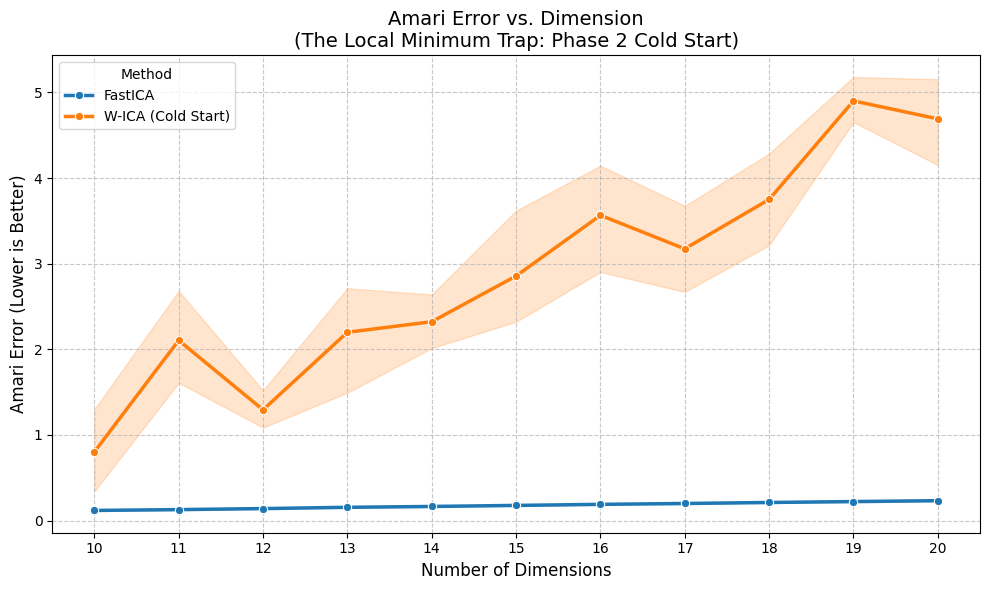

In [9]:
# ==========================================
# 4. Plotting the Cold Start Divergence
# ==========================================

plt.figure(figsize=(10, 6))

# Plot the Amari Error curves
sns.lineplot(
    data=df, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    marker='o', 
    linewidth=2.5,
    palette=['#1f77b4', '#ff7f0e'] # Force consistent colors (FastICA Blue, W-ICA Orange)
)

plt.title("Amari Error vs. Dimension\n(The Local Minimum Trap: Phase 2 Cold Start)", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS) # Ensure every dimension is ticked from 10 to 20
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()